In [ ]:
# Distributional Semantics — practical session.

#Here I collected some examples and exercises that implement different word embedding models (word2Vec, GloVe, fastText, and BERT).
#Each can be used for the same or different task depending on what is needed. Below you have code that implements the most popular functions.
#Under almost every code chunk there is an "exercise:..." for you to try it out yourself

# You will:
# 1) Train a small Word2Vec on a paragraph
# 2) Use pretrained GloVe and fastText models
# 3) Compute cosine similarity & nearest neighbours
# 4) Try analogies and vector arithmetics (king - man + woman ≈ ?)
# 5) Compare contextual embeddings in BERT (river-bank vs financial bank)
# 6) Visualize a small word map with PCA

# **Word2Vec**

In [1]:
%pip uninstall -y -q opencv-python opencv-contrib-python opencv-python-headless umap-learn thinc albucore albumentations dopamine-rl tsfresh

In [2]:
#Setup: install libraries (first run takes ~1–2 minutes)
%pip install -q "numpy==1.26.4" "thinc==8.3.4" "scipy<1.14" "scikit-learn<1.6" "gensim==4.3.3" "transformers==4.44.2" -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 29.9 MB/s eta 0:00:00


>Note: Now **restart** session (Runtime => Restart session), before proceeding to the cells below

In [1]:
#Loading a paragraph of text
paragraph = """
Distributional semantics is a method for modeling word meaning.
Words that occur in similar contexts have similar meanings.
Word embeddings represent words as vectors in a semantic space.
Similar meanings are closer in that space.
We can measure similarity with cosine similarity and nearest neighbours.
This is a small example for a workshop.
""".strip()

#exercise: add your own sentences to "paragraph", re‑run the next 3 code chunks, and watch neighbours change.

In [2]:
#Text preprocessing (simple tokenization): lowercase + split
sentences = [line.lower().split() for line in paragraph.split("\n") if line.strip()]
print("Number of sentences:", len(sentences))
print("Example sentence tokens:", sentences[0])

Number of sentences: 6
Example sentence tokens: ['distributional', 'semantics', 'is', 'a', 'method', 'for', 'modeling', 'word', 'meaning.']


In [3]:
#Training a very small Word2Vec model on our example text
from gensim.models import Word2Vec

w2v_small = Word2Vec(
    sentences, #our data (tokenized paragraph)
    vector_size=50, #dimensionality
    window=3, #context window size
    min_count=1, #minimum number of times a word must appear
    workers=2, #number of CPU cores used in training
    epochs=200) #training passes over the whole dataset
print("\n We trained a tiny Word2Vec on the paragraph.")
print("Vocabulary:", sorted(w2v_small.wv.key_to_index.keys()))


 We trained a tiny Word2Vec on the paragraph.
Vocabulary: ['a', 'and', 'are', 'as', 'can', 'closer', 'contexts', 'cosine', 'distributional', 'embeddings', 'example', 'for', 'have', 'in', 'is', 'meaning.', 'meanings', 'meanings.', 'measure', 'method', 'modeling', 'nearest', 'neighbours.', 'occur', 'represent', 'semantic', 'semantics', 'similar', 'similarity', 'small', 'space.', 'that', 'this', 'vectors', 'we', 'with', 'word', 'words', 'workshop.']


In [4]:
#Cosine similarity and nearest neighbours based on our text
import numpy as np
from numpy.linalg import norm

def cosine_sim(u, v):
    u = np.array(u); v = np.array(v)
    if norm(u) == 0 or norm(v) == 0:
        return 0.0
    return float(np.dot(u, v) / (norm(u) * norm(v)))

pairs = [("words","meaning"), ("similar","meanings"), ("semantics","space"), ("cosine","similarity")]
print("\nCosine similarities:")
for a,b in pairs:
    if a in w2v_small.wv and b in w2v_small.wv:
        print(f"{a:>10} ~ {b:<10} -> {cosine_sim(w2v_small.wv[a], w2v_small.wv[b]):.3f}")

target = "similar"
if target in w2v_small.wv:
    print(f"\nNearest neighbours of '{target}':")
    print(w2v_small.wv.most_similar(target, topn=5))

#exercise: change "target" and see nearest neighbours of other words from the paragraph in the Word2Vec model.


Cosine similarities:
   similar ~ meanings   -> 0.384
    cosine ~ similarity -> 0.359

Nearest neighbours of 'similar':
[('a', 0.4332371950149536), ('for', 0.41999348998069763), ('semantic', 0.40230751037597656), ('meanings', 0.38373708724975586), ('small', 0.38142725825309753)]


# **GloVe**

In [5]:
#Using pretrained embeddings from a GloVe model (loading the GloVe model)
import gensim.downloader as api
glove = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [6]:
#Neirest negihbors and cosine similarity
print("\nGloVe neighbours of 'dog':") #you can change the word to any word you like
print(glove.most_similar("dog")[:10])

print("\nGloVe cosine similarity: 'dog' vs 'cat'")
print(glove.similarity("dog","cat"))

#exercise: a) replace "dog" with other words to see the nearest neighbors
#          b) replace "dog" and "cat" and compute glove.similarity("dog","cat"). Try also unrelated pairs of words.


GloVe neighbours of 'dog':
[('cat', 0.8798074126243591), ('dogs', 0.8344309329986572), ('pet', 0.7449564337730408), ('puppy', 0.723637580871582), ('horse', 0.7109653949737549), ('animal', 0.6817063093185425), ('pig', 0.655417263507843), ('boy', 0.6545308232307434), ('cats', 0.6471932530403137), ('rabbit', 0.6468630433082581)]

GloVe cosine similarity: 'dog' vs 'cat'
0.8798075


In [7]:
#Vector arithmetics using GloVe model
print("\nVector arithmetics with GloVe: king - man + woman ≈ ?")
arithmetics_glove = glove.most_similar(positive=["king","woman"], negative=["man"], topn=5)
print(arithmetics_glove)

#exercise: play around with different words - replace "king", "man", "woman" e.g. try capitals and countries "glove.most_similar(positive=["paris","italy"], negative=["france"])"


Vector arithmetics with GloVe: king - man + woman ≈ ?
[('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473), ('daughter', 0.6594556570053101), ('princess', 0.6520534157752991)]


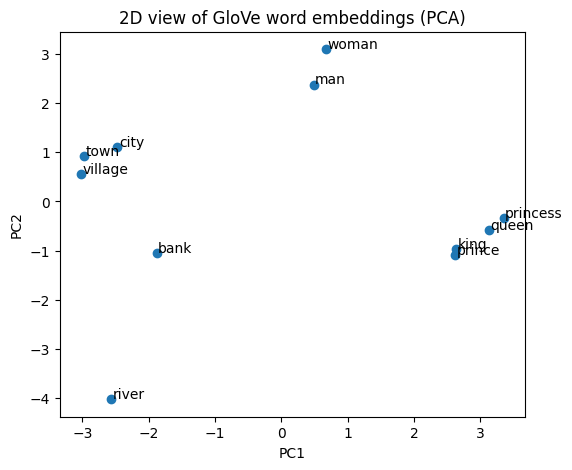

In [8]:
#Visualizing with PCA (2D map of a few words) with GloVe model
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

words = ["king","queen","man","woman","prince","princess","city","town","village","river","bank"]
words = [w for w in words if w in glove.key_to_index]
X = np.stack([glove[w] for w in words])

pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1])
for (x,y,w) in zip(X2[:,0], X2[:,1], words):
    plt.text(x+0.02, y+0.02, w)
plt.title("2D view of GloVe word embeddings (PCA)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

#exercise: change "words" to a themed list (animals, colors, emotions) and re‑plot (re-run the code)

In [9]:
#outlier detection
glove.doesnt_match(["red","blue","green","banana"])

'banana'

# **fastText**

In [10]:
#Using pretrained embeddings from a fastText model (loading the fastText model)
import gensim.downloader as api
fasttext = api.load("fasttext-wiki-news-subwords-300")

[==================================================] 100.0% 958.5/958.4MB downloaded


In [11]:
print("fastText neighbours of 'university':")
print(fasttext.most_similar("university")[:10])

print("\nfastText cosine similarity: 'black' vs 'white'")
print(fasttext.similarity("black","white"))

#exercise: a) replace "univeristy" with other words to see the nearest neighbors
#          b) replace "black" and "white" and compute fasttext.similarity("black","white"). Try also unrelated pairs of words.

fastText neighbours of 'university':
[('college', 0.8344717621803284), ('university-college', 0.7878896594047546), ('non-university', 0.772835910320282), ('campus', 0.7692064046859741), ('institution', 0.7676444053649902), ('universities', 0.7637246251106262), ('univerity', 0.7594793438911438), ('universitys', 0.7547542452812195), ('university-', 0.7454743981361389), ('University', 0.7438970804214478)]

fastText cosine similarity: 'black' vs 'white'
0.9345934


In [12]:
#Cosine similarity function
def cosine_sim_by_word(a, b, kv):
    va = kv.get_vector(a)
    vb = kv.get_vector(b)
    return float(np.dot(va, vb) / (norm(va) * norm(vb)))

#Show similarities + neighbours for lemma + forms
def show_morphology(lemma, forms, kv, topn=5):
    print(f"\n=== Lemma: '{lemma}' ===")
    for form in forms:
        sim = cosine_sim_by_word(lemma, form, kv)
        print(f"{lemma:>12} ~ {form:<12} -> cosine = {sim:.3f}")
    print(f"\nNearest neighbours of '{lemma}':")
    print(kv.most_similar(lemma, topn=topn))
    for form in forms:
        print(f"\nNearest neighbours of '{form}':")
        print(kv.most_similar(form, topn=topn))

#Try a few English morphology sets
morph_sets = [
    ("run",   ["runs", "running"]),
    ("walk",  ["walks", "walking"]),
    ("study", ["studies", "studying"]),
    ("happy", ["happier", "happiest"]),
    ("play",  ["plays", "playing"]),
]

for lemma, forms in morph_sets:
    show_morphology(lemma, forms, fasttext, topn=2)

#Morphology analogy
print("\n=== Morphology analogy: run : running :: walk : ? ===")
ans = fasttext.most_similar(positive=["running", "walk"], negative=["run"], topn=5)
print(ans)


=== Lemma: 'run' ===
         run ~ runs         -> cosine = 0.747
         run ~ running      -> cosine = 0.820

Nearest neighbours of 'run':
[('running', 0.8197714686393738), ('ran', 0.7697737216949463)]

Nearest neighbours of 'runs':
[('run', 0.7466383576393127), ('parkruns', 0.7040348052978516)]

Nearest neighbours of 'running':
[('runnning', 0.8452346324920654), ('run', 0.819771409034729)]

=== Lemma: 'walk' ===
        walk ~ walks        -> cosine = 0.662
        walk ~ walking      -> cosine = 0.717

Nearest neighbours of 'walk':
[('walking', 0.717042863368988), ('cross-walk', 0.7055902481079102)]

Nearest neighbours of 'walks':
[('walking', 0.7496265172958374), ('strolls', 0.6978815793991089)]

Nearest neighbours of 'walking':
[('walks', 0.7496265769004822), ('walked', 0.7278099060058594)]

=== Lemma: 'study' ===
       study ~ studies      -> cosine = 0.820
       study ~ studying     -> cosine = 0.672

Nearest neighbours of 'study':
[('studies', 0.8199716210365295), ('sub-s

In [13]:
#outlier detection
fasttext.doesnt_match(["car","bus","tram","desk"])

'desk'

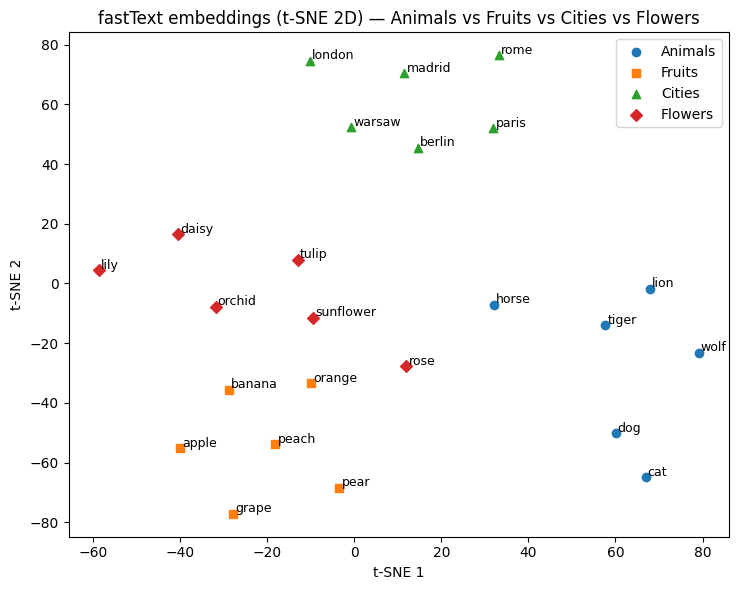

In [14]:
categories = {
    "Animals": ["dog", "cat", "lion", "tiger", "wolf", "horse"],
    "Fruits":  ["apple", "banana", "orange", "grape", "pear", "peach"],
    "Cities":  ["paris", "london", "berlin", "rome", "madrid", "warsaw"],
    "Flowers": ["rose", "tulip", "lily", "orchid", "daisy", "sunflower"],
}

# 3) Get vectors for every word (fastText provides get_vector even for OOV)
words = []
labels = []
for group, items in categories.items():
    for w in items:
        words.append(w)
        labels.append(group)

X = np.stack([fasttext.get_vector(w) for w in words])  # shape: [N, 300]
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=10, random_state=0)
X2_tsne = tsne.fit_transform(X)

plt.figure(figsize=(7.5, 6))
markers = {"Animals": "o", "Fruits": "s", "Cities": "^", "Flowers": "D"}

for group in categories.keys():
    idx = [i for i, g in enumerate(labels) if g == group]
    plt.scatter(X2_tsne[idx, 0], X2_tsne[idx, 1], marker=markers[group], label=group)
    for i in idx:
        plt.text(X2_tsne[i, 0] + 0.5, X2_tsne[i, 1] + 0.5, words[i], fontsize=9)

plt.title("fastText embeddings (t‑SNE 2D) — Animals vs Fruits vs Cities vs Flowers")
plt.xlabel("t‑SNE 1")
plt.ylabel("t‑SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

# **BERT**

In [15]:
#Using contextual embeddings with BERT (loading BERT model)
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from numpy.linalg import norm

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased") #each token gets mapped to a hidden vector of size 768
bert_model.eval()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [16]:
# Using contextual embeddings with BERT
sentence_a = "The bank is next to the river."
sentence_b = "I need to go to the bank to open an account."

with torch.no_grad():
    tokens_a = bert_tokenizer(sentence_a, return_tensors="pt") #tokenization
    tokens_b = bert_tokenizer(sentence_b, return_tensors="pt")
    out_a = bert_model(**tokens_a).last_hidden_state[0]  #getting all word embeddings in sentence_a
    out_b = bert_model(**tokens_b).last_hidden_state[0]  #getting all word embeddings in sentence_b

bank_id = bert_tokenizer.convert_tokens_to_ids("bank")
idx_a = (tokens_a.input_ids[0] == bank_id).nonzero(as_tuple=True)[0] #index of "bank" in sentence_a
idx_b = (tokens_b.input_ids[0] == bank_id).nonzero(as_tuple=True)[0] #index of "bank" in sentence_b

def cosine_sim(u, v):
    if norm(u) == 0 or norm(v) == 0:
        return 0.0
    return float(np.dot(u, v) / (norm(u) * norm(v)))

if len(idx_a) and len(idx_b):
    vec_a = out_a[idx_a[0]].numpy() #vec_a = embedding for "bank" in river bank context
    vec_b = out_b[idx_b[0]].numpy() #vec_b = embedding for "bank" in financial bank context
    print("BERT cosine similarity for 'bank' in two contexts (river vs finance):", cosine_sim(vec_a, vec_b))

#exercise: modify the two bank sentences (river vs finance); compare BERT cosine similarity. Use ambiguous words like "bat" (the animal vs baseball bat), apple (the fruit vs the company) etc.

BERT cosine similarity for 'bank' in two contexts (river vs finance): 0.4956289529800415
